In [37]:
import pandas as pd
import string

# No max rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

olympics_df = pd.read_csv('athlete_events.csv')
noc_regions_df = pd.read_csv('noc_regions.csv')

In [53]:
# Examining main dataset
olympics_df.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Won_Medal,Height_missing
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,False,False
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,False,True
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,True,True
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,False,False
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,False,False
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN,False,False
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,False,False
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN,False,False
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN,False,False


In [55]:
# Examining secondary dataset
noc_regions_df.head(10)

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN
5,ANG,Angola,NaN
6,ANT,Antigua,Antigua and Barbuda
7,ANZ,Australia,Australasia
8,ARG,Argentina,NaN
9,ARM,Armenia,NaN


In [56]:
print(f"Rows: {olympics_df.shape[0]} Columns: {olympics_df.shape[1]}\n")
print(olympics_df.info())

Rows: 271116 Columns: 17

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   ID              271116 non-null  int64   
 1   Name            271116 non-null  string  
 2   Sex             271116 non-null  category
 3   Age             261642 non-null  float64 
 4   Height          210945 non-null  float64 
 5   Weight          208241 non-null  float64 
 6   Team            271116 non-null  category
 7   NOC             271116 non-null  category
 8   Games           271116 non-null  category
 9   Year            271116 non-null  int64   
 10  Season          271116 non-null  category
 11  City            271116 non-null  category
 12  Sport           271116 non-null  category
 13  Event           271116 non-null  category
 14  Medal           39783 non-null   category
 15  Won_Medal       271116 non-null  bool    
 16  Height_missi

**Observations:**

- Some heights and weights are NaN
- If an athlete didn't win a medal (gold, silver, or bronze) then they have NaN
- Multiple entries for each event an athlete competes in (so one athlete can have many entries)
- Does not include Olympics more recent than 2016
- Types of columns that are strings are objects (such as Name, Team, City, Medal, etc.)

**Data Prepocessing:**
- Convert categorical columns to categories
- Convert names to strings
- Add column for indicating if medal was won

In [57]:
categorical_cols = [
    'Sex', 'Team', 'NOC', 'Games',
    'Season', 'City', 'Sport', 'Event', 'Medal'
]

for col in categorical_cols:
    olympics_df[col] = olympics_df[col].astype('category')

olympics_df['Name'] = olympics_df['Name'].astype('string')

olympics_df['Won_Medal'] = olympics_df['Medal'].notna()

**Investigate Missing Values:**

In [58]:
# Yields percentage of height and weight data that is missing
olympics_df[['Height', 'Weight']].isna().mean()

Height    0.221938
Weight    0.231912
dtype: float64

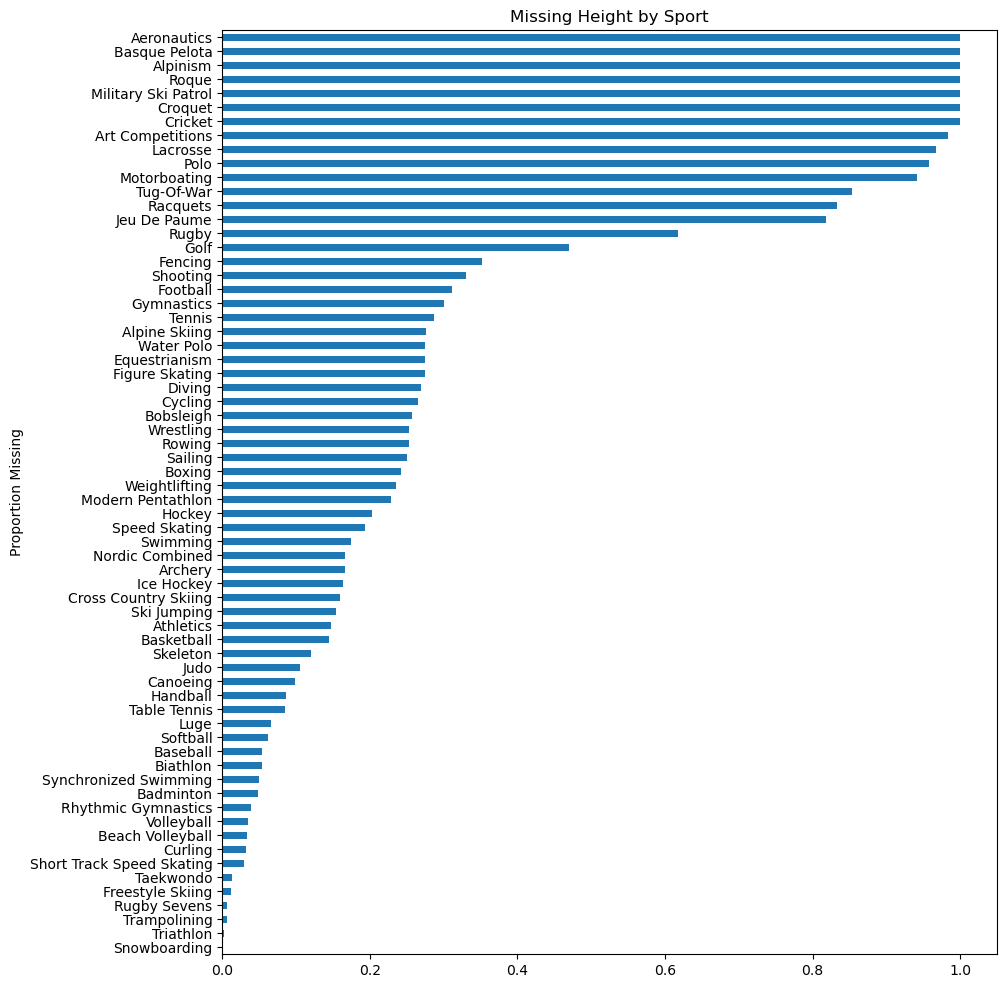

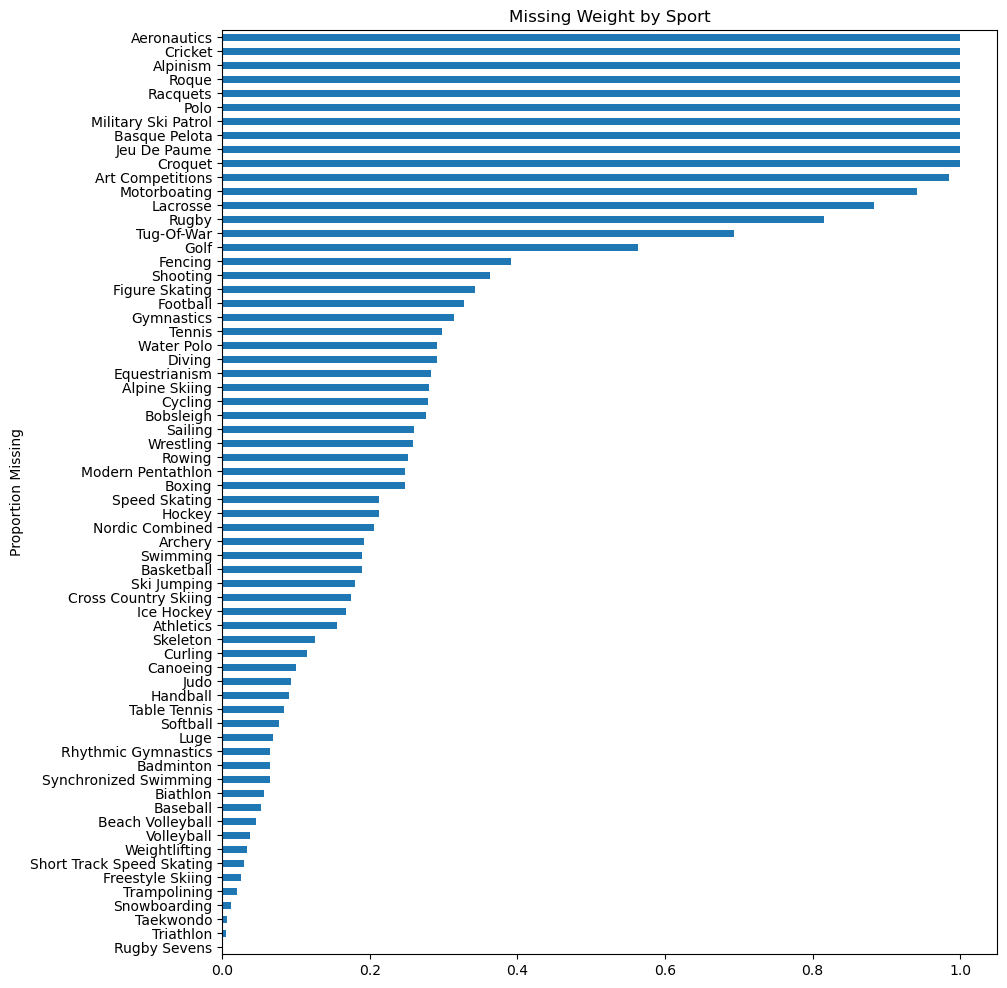

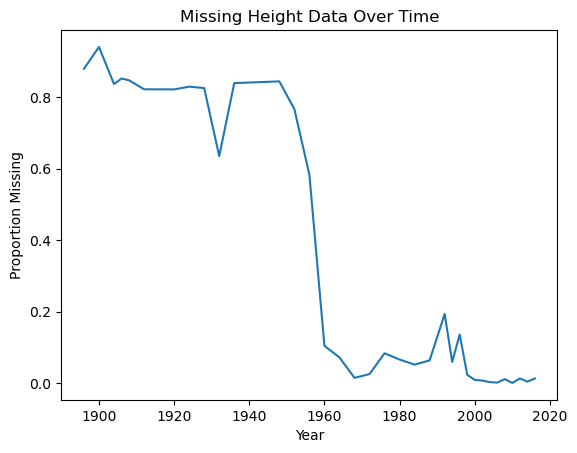

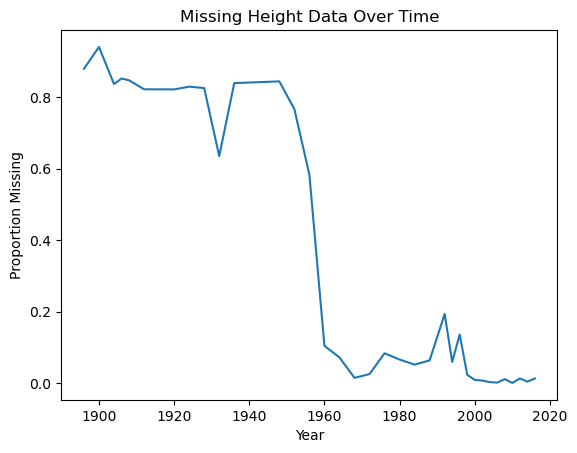

In [62]:
# Plot missingingness
import matplotlib.pyplot as plt

olympics_df['Height_missing'] = olympics_df['Height'].isna()
olympics_df['Weight_missing'] = olympics_df['Weight'].isna()

# Missingness by sport
# Height
missing_by_sport_height = olympics_df.groupby('Sport', observed=False)['Height_missing'].mean().sort_values(ascending=False)
missing_by_sport_height.sort_values().plot(kind='barh', figsize=(10,12))
plt.title("Missing Height by Sport")
plt.ylabel("Proportion Missing")
plt.show()

# Weight
missing_by_sport_weight = olympics_df.groupby('Sport', observed=False)['Weight_missing'].mean().sort_values(ascending=False)
missing_by_sport_weight.sort_values().plot(kind='barh', figsize=(10,12))
plt.title("Missing Weight by Sport")
plt.ylabel("Proportion Missing")
plt.show()

# Missingness by year
# Height
missing_by_year_height = olympics_df.groupby('Year')['Height_missing'].mean()
missing_by_year_height.plot()
plt.title("Missing Height Data Over Time")
plt.ylabel("Proportion Missing")
plt.show()

# Weight
missing_by_year_weight = olympics_df.groupby('Year')['Height_missing'].mean()
missing_by_year_weight.plot()
plt.title("Missing Height Data Over Time")
plt.ylabel("Proportion Missing")
plt.show()

**Conclusion:**
Missing height and weight data are not randomly distributed, but instead vary significantly by sport and year. As shown in the plots, the highest proportion of missing height and weight data comes from before 1960 and certain sports have little to no height and weight data. We can also see that missing height and weight almost always occurs simultaneously. This will influence how we handle missing height and weight values in the future.

**Investigating Impact of Height and Weight on Medals:**

**Method:** Hypothesis Testing (t-test)

**Question:** Do medalists differ physically from non-medalists?

**Null Hypothesis:** There is no difference in the mean age between athletes who did and did not win a medal.

**Alternative Hypothesis:** There is a difference in the mean age between athletes who did and did not win a medal

In [67]:
from scipy.stats import ttest_ind

# Age is not missing and won a medal
medalists = olympics_df[olympics_df['Medal'].notna()]['Age'].dropna()

# Age not missing and did not win a medal
non_medalists = olympics_df[olympics_df['Medal'].isna()]['Age'].dropna()

# Two-sided t-test
t_stat, p_val = ttest_ind(medalists, non_medalists, equal_var=False)  # Welch's t-test
print("t-statistic:", t_stat)
print("p-value:", p_val)

t-statistic: 13.149116533879518
p-value: 1.9665810699587392e-39


**Interpretation:**

The p-value is less than 0.01, therefore reject the null hypothesis, supporting that mean age does differ between medalists and non-medalists.

**Investigating Physical Traits vs. Medal Winning:**

In [71]:
# Convert boolean to int for correlation
olympics_df['Won_Medal_Int'] = olympics_df['Won_Medal'].astype(int)

# Correlation matrix
corr = olympics_df[['Age', 'Height', 'Weight', 'Won_Medal_Int']].corr()
print(corr)

                    Age    Height    Weight  Won_Medal_Int
Age            1.000000  0.138246  0.212069       0.024126
Height         0.138246  1.000000  0.796213       0.087532
Weight         0.212069  0.796213  1.000000       0.088510
Won_Medal_Int  0.024126  0.087532  0.088510       1.000000


**Interpretation:**

Height vs Won_Medal_Int = 0.0885
Weight vs Won_Medal_Int = 0.0875
Age vs Won_Medal_Int = 0.0241

These are very weak positive correlations. There is a slight tendency for taller/heavier athletes to win medals. Age has almost no correlation with medal-winning. This suggests that across all sports, no single physical characteristic strongly predicts whether an athlete wins a medal. This likely reflects the fact that different sports favor different physical profiles.